# LDH Adsorption – original dataset (Qe mg/g & RR %)
Runs the corrected pipeline on the original `Data/Data_Adsorption.xlsx` (1343 rows × 30 cols, 33 source studies) for **both** targets, on the primary interpolation protocol.

> In the previous version the two targets shared mutable globals: the RR split overwrote the Qe split, so Qe SHAP/importance were computed on rows the Qe model had trained on. Each target now runs as an isolated experiment.

> **Scope of the claim.** The dataset's 1342 rows come from **59 source studies**: within one
> study, the material and pollutant descriptors are constant and only the operating conditions
> (pH, temperature, time, dosage, Ci) vary. These models are therefore trained and validated to
> **predict RR % for *studied* material–pollutant systems at new operating conditions**
> (within-system interpolation, row-level split with exact-duplicate rows removed).
> They are **not** validated for screening unseen materials or pollutants: a grouped split by
> source study (reported in the main notebook as a limitation analysis) shows near-zero
> cross-study R². Do not cite the interpolation metrics as evidence of screening power.

> **Methodology notes (rewrite, 2026-09):** rebuilt on the shared
> [`ldh_pipeline.py`](ldh_pipeline.py) module after a code review. Scores are reported as three
> honestly-labeled numbers (train / CV validation / hold-out test); KNN imputation, scaling and
> encoding live inside each model's Pipeline (fit on training folds only); RR % is normalized
> range-aware to [0, 100]; exact feature-duplicate rows are removed before splitting; every
> split, CV fold, and Optuna sampler is seeded; each experiment saves models + scores + config
> under its own `Model/<experiment_name>/` folder.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
# On Colab: clone/mount the repo and point this at its notebooks/ folder.
sys.path.insert(0, str(Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ldh_pipeline as lp

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 12,
})
SEED = lp.SEED
print('Data dir :', lp.DATA_DIR)
print('Model dir:', lp.MODEL_DIR)

Data dir : /home/trunght/workspace/researches/Green-X Project-BaoTien/Data
Model dir: /home/trunght/workspace/researches/Green-X Project-BaoTien/Model


In [2]:
df = lp.load_data(lp.DATA_DIR / 'Data_Adsorption.xlsx')
print(f"Shape: {df.shape} | studies: {df['Id'].nunique()}")
MODELS = ("LR", "KNN", "ANN", "Cubist", "RF", "XGB", "HistGB")
runs = {}
for target, name in [('Qe mg/g', 'orig_qe_interp_42'), ('RR %', 'orig_rr_interp_42')]:
    print(f"\n================ {name} ================")
    cfg = lp.ExperimentConfig(name=name, data_file='Data_Adsorption.xlsx', target=target,
                              split_mode='row', dedup_features=True, models=MODELS)
    runs[name] = lp.run_experiment(cfg, df)

Shape: (1343, 30) | studies: 33

================ orig_qe_interp_42 ================
[orig_qe_interp_42] dropped 83 exact feature-duplicate rows
[orig_qe_interp_42] split=row  train=1002  test=251  features=25
--- Optuna tuning RF (30 trials) ---


[*] RF best params: {'n_estimators': 430, 'max_depth': 13, 'min_samples_leaf': 3}
--- Optuna tuning XGB (30 trials) ---


[*] XGB best params: {'n_estimators': 101, 'learning_rate': 0.4953800528834236, 'max_depth': 14, 'min_child_weight': 6}
--- Optuna tuning HistGB (30 trials) ---


[*] HistGB best params: {'max_iter': 580, 'learning_rate': 0.23698860153613402, 'max_depth': 11, 'min_samples_leaf': 6}
--- LR ---


    Train      R2  0.7565 | MAE  46.8542
    CV (valid) R2  0.7222 | MAE  48.6371
    Test       R2  0.8514 | MAE  38.2916

--- KNN ---


...

[*] best params: {'n_committees': 8, 'neighbors': 2}


    Train      R2  0.9121 | MAE   5.2797
    CV (valid) R2  0.7868 | MAE   8.7208
    Test       R2  0.7743 | MAE   8.4133

--- RF ---


    Train      R2  0.9048 | MAE   5.8243
    CV (valid) R2  0.7702 | MAE   9.3369
    Test       R2  0.7616 | MAE   8.9132

--- XGB ---


    Train      R2  0.9930 | MAE   1.2848
    CV (valid) R2  0.8291 | MAE   6.9084
    Test       R2  0.8322 | MAE   6.0328

--- HistGB ---


    Train      R2  0.9991 | MAE   0.5247
    CV (valid) R2  0.8317 | MAE   6.7447
    Test       R2  0.8219 | MAE   6.1803



In [3]:
for name, run in runs.items():
    print(f"\n=== {name} ===")
    print(run['table'].round(3))


=== orig_qe_interp_42 ===
        train_r2  cv_r2  test_r2  train_mae  cv_mae  test_mae  test_rmse
Cubist     0.995  0.946    0.984      3.120  12.421     7.702     19.958
HistGB     1.000  0.919    0.971      0.739  15.076     9.291     26.731
XGB        0.998  0.939    0.973      1.585  15.587    10.009     25.753
KNN        1.000  0.910    0.954      0.010  14.646    10.188     33.900
RF         0.960  0.874    0.976     12.452  21.096    10.664     24.588
ANN        0.841  0.789    0.917     34.189  38.894    29.339     45.523
LR         0.756  0.722    0.851     46.854  48.637    38.292     60.934

=== orig_rr_interp_42 ===
        train_r2  cv_r2  test_r2  train_mae  cv_mae  test_mae  test_rmse
XGB        0.993  0.829    0.832      1.285   6.908     6.033     11.244
HistGB     0.999  0.832    0.822      0.525   6.745     6.180     11.584
KNN        0.937  0.735    0.769      3.750   8.556     7.609     13.203
Cubist     0.912  0.787    0.774      5.280   8.721     8.413     13.0

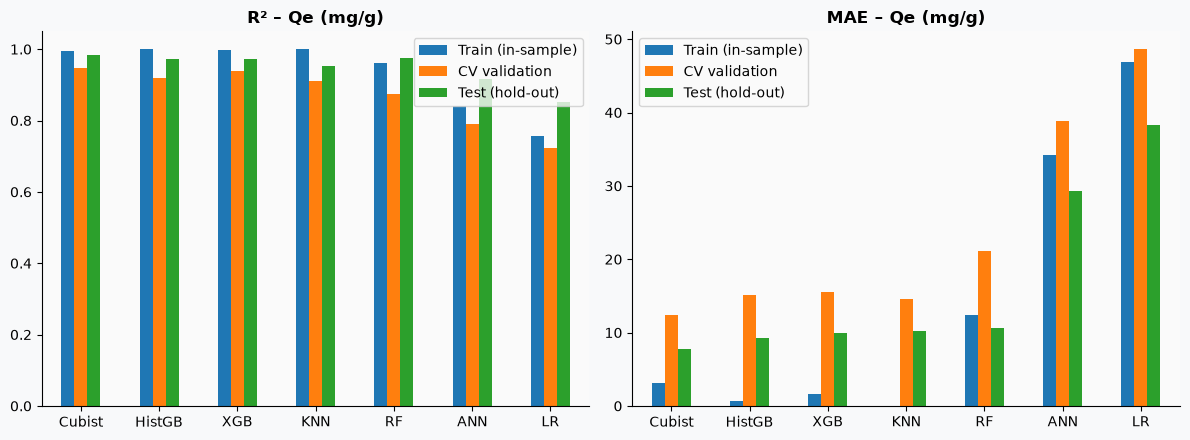

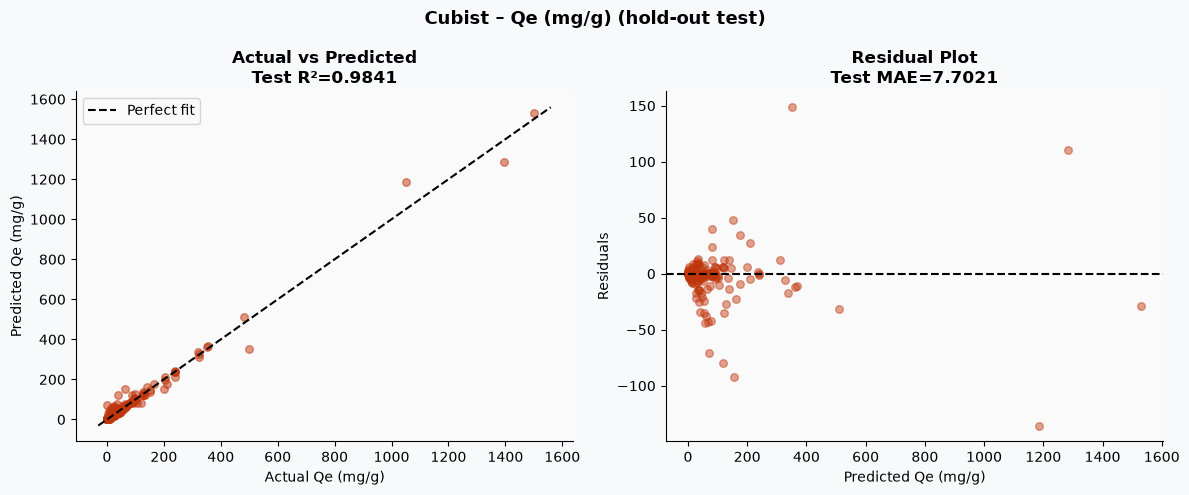

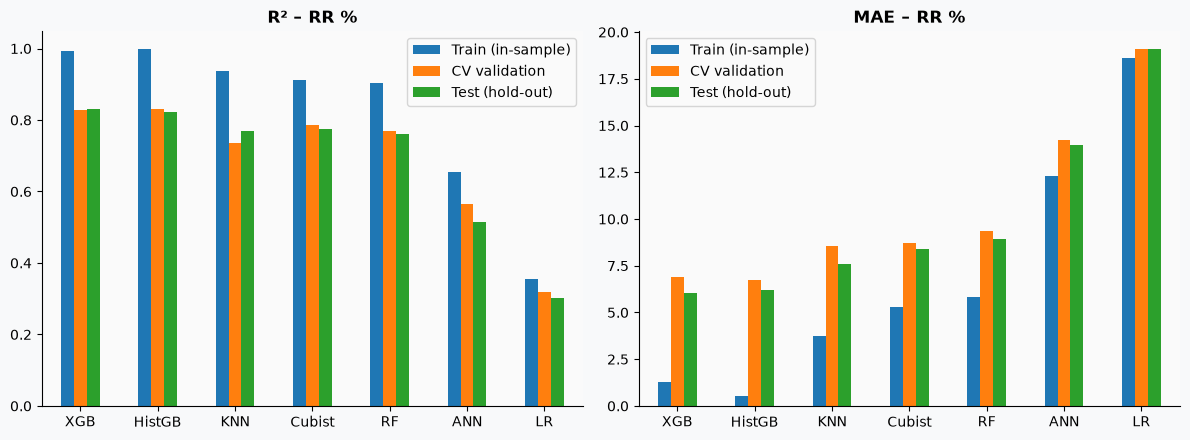

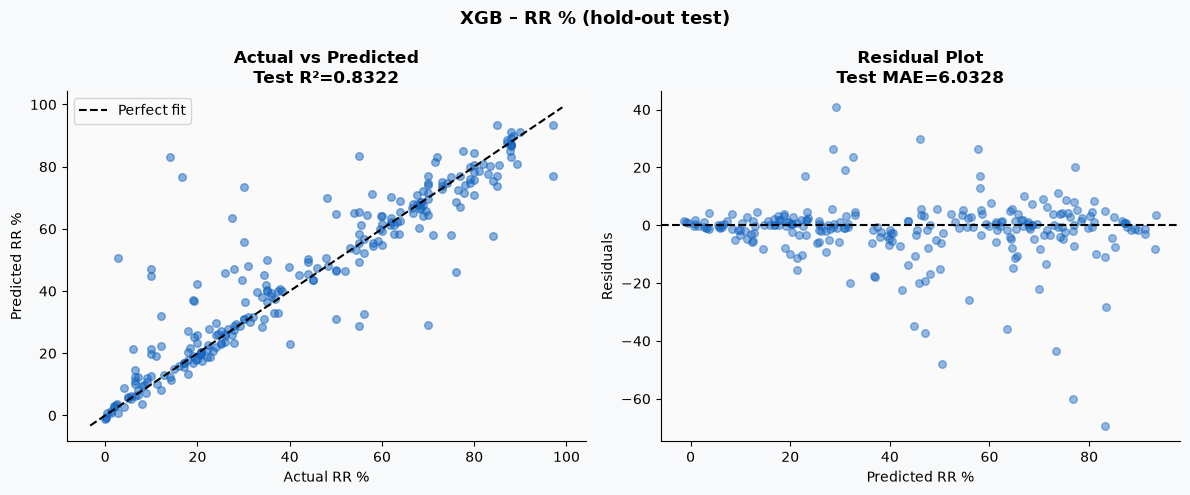

In [4]:
for name, run in runs.items():
    target_label = 'Qe (mg/g)' if 'qe' in name else 'RR %'
    color = '#BF360C' if 'qe' in name else '#1565C0'
    lp.plot_model_comparison(run['table'], target_label,
                             out_path=run['out_dir'] / 'model_results.png')
    best = run['table'].index[0]
    lp.plot_parity(run['results'][best], target_label, color=color,
                   out_path=run['out_dir'] / 'best_model_parity.png')

In [5]:
for name, run in runs.items():
    ranks = lp.permutation_ranks(run['results'], run['X_test'], run['y_test'])
    ranks.to_csv(run['out_dir'] / 'permutation_importance.csv')
    print(f"\n=== {name}: permutation-importance ranks (test set) ===")
    print(ranks.sort_values(ranks.columns[-1]).head(10))


=== orig_qe_interp_42: permutation-importance ranks (test set) ===
          LR  KNN  ANN  Cubist  RF  XGB  HistGB
Ci mg/L    2    1    1       1   1    1       1
PV cm3/g   9   15   14      11   3    2       2
AD g/L    12   13    7       3   2    3       3
2theta    11   11   11       6  12    4       4
MW g/mol   1   12   15      19  15    5       5
Time h     5    6    3       2   4    6       6
pHpzc     18    9   18       4   6    7       7
Log Kow    7   20    5      16  17   12       8
pH        17    3   17      10   8   11       9
BET m2/g  19    4   22       8   7   13      10



=== orig_rr_interp_42: permutation-importance ranks (test set) ===
          LR  KNN  ANN  Cubist  RF  XGB  HistGB
AD g/L    22    1   17       1   1    1       1
Time h    12    2    1       2   2    2       2
pH         7    3    4       4   4    4       3
PV cm3/g   9   18   18       3   3    3       4
Ci mg/L   15    4   13       5   5    6       5
Method     8   25    7      23   7    5       6
BET m2/g  24    5    5      10   6    7       7
Log Kow   17    8   20      13  13    9       8
2theta    11   24   25      16  20    8       9
E          6   15    2       7   9   11      10
